<a href="https://colab.research.google.com/github/w3aarush/deep-learning/blob/main/MNIST_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# starting the assembly line
model = Sequential()

# first layer - convolutional layer
# applying 32 filters, each of 3 x 3
# input_shape = (28, 28) means a 28 x 28 pixel image with 1 color channel (grayscale)
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# second layer - pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# the flatten layer
# unroll the 2D data into a 1D straight line
model.add(Flatten())

# The Output Layer
# 10 neurons for our 10 possible categories, using Softmax
model.add(Dense(10, activation='softmax'))

# compile the model just like we did before
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print('CNN Architecture Successfull')

CNN Architecture Successfull


In [ ]:
# loading the MNIST dataset
from tensorflow.keras.datasets import mnist
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# preparing the data (scaling and reshaping)
# neural network prefer numbers between 0 and 1
# pixel values go from 0 to 255, so we divide by 255 to scale them.
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# CNN's specifically expect data in 4D format: (Number of images, height, width, color_channel)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

### training the model

In [ ]:
print("Starting training..........")
# train for 5 epochs ( looping over the whole dataset 5 times)
# batch_size=32 means it updates weights after looking at 32 images at a time
model.fit(X_train, y_train, epochs=8, batch_size=32, validation_data=(X_test, y_test))

Starting training..........
Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9412 - loss: 0.2076 - val_accuracy: 0.9740 - val_loss: 0.0898
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9776 - loss: 0.0770 - val_accuracy: 0.9804 - val_loss: 0.0656
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9832 - loss: 0.0584 - val_accuracy: 0.9822 - val_loss: 0.0567
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9859 - loss: 0.0476 - val_accuracy: 0.9833 - val_loss: 0.0530
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0401 - val_accuracy: 0.9819 - val_loss: 0.0611
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9896 - loss: 0.0344 - val_accuracy: 0.9843 - val_loss: 0.0496
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9907 - loss: 0.0293 - val_accuracy: 0.9821 - val_loss: 0.0559
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.99

## using the model to predict

In [ ]:
test_image = X_test[18:19]

prediction_prob = model.predict(test_image)
print(prediction_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[4.5585353e-09 5.3157310e-13 1.0907659e-05 2.2563308e-02 6.4026104e-09
  4.4406857e-03 6.5299872e-09 8.2569649e-08 9.7294134e-01 4.3598066e-05]]


In [ ]:
# find the highest probabilities out of the 10 output nodes
import numpy as np
predicted_number = np.argmax(prediction_prob[0]) # np.argmax returns index of the highest value in the array
actual_number = y_test_raw[18]

In [ ]:
print(f"The model predicted number: {predicted_number}")
print(f"The actual number was: {actual_number}")

The model predicted number: 8
The actual number was: 3


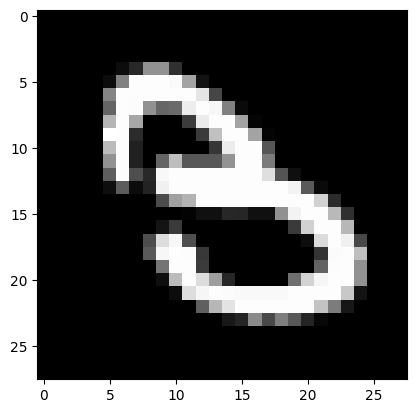

In [ ]:
plt.imshow(X_test_raw[18], cmap='gray')
plt.show()

In [ ]:
model.save('mnist_cnn_classifier.keras') # a way to extract/save the model

In [ ]:
from tensorflow.keras.models import load_model
depoloyed_model = load_model('mnist_cnn_classifier.keras')
print("Model successfully loaded and ready for deployment")

Model successfully loaded and ready for deployment
